In [1]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison

## Analysis of Larger experiments


In [2]:
bpr_unbiased_calibrated_time = "experiments/yelp/bpr_unbiased_calibrated_time_based_large.yaml"
bpr_unbiased_calibrated_steck = "experiments/yelp/bpr_unbiased_calibrated_constant_large.yaml"

bpr_debiased = "experiments/yelp/bpr_unbiased_uncalibrated_large.yaml"

random_rec = "experiments/yelp/random_rec_uncalibrated_large.yaml"
most_popular = "experiments/yelp/most_popular_uncalibrated_large.yaml"

### Analise do MAP


Mesmo pra n maior, ta esquisito. Talvez seja um problema de como eu avalio esse cara

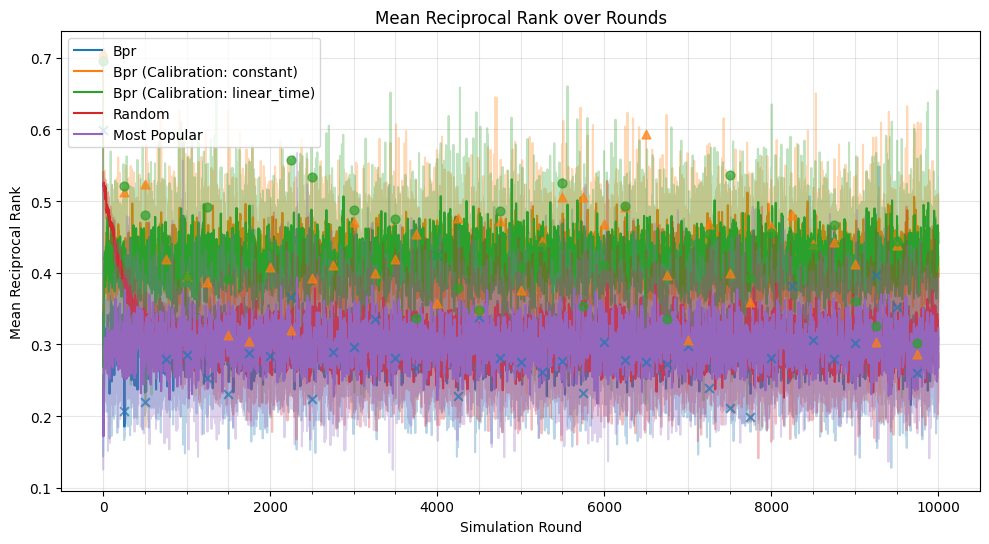

In [3]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="mrr", title=None, graph="line", plot_retrain_points=True,  window_size=5)

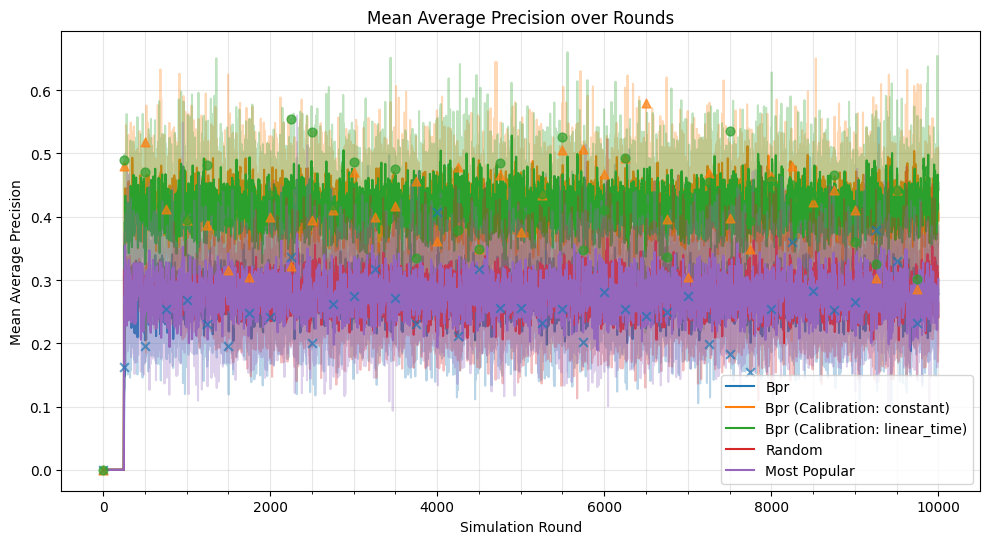

In [4]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="map", title=None, graph="line", plot_retrain_points=True,  window_size=5)

### Taste distortion between recommendation and initial state



Conclusões bem parecidas em relação ao N pequeno: calibração cai ao longo do tempo. Curiosamente calibração ficou pior pro caso do yelp. 

A mesma conclusão não ocrre pro MACE. Então deve ser algo rank-sensitive. Talvez a lista como um todo esteja mais mal calibrada, mas o top5 esteja bom?

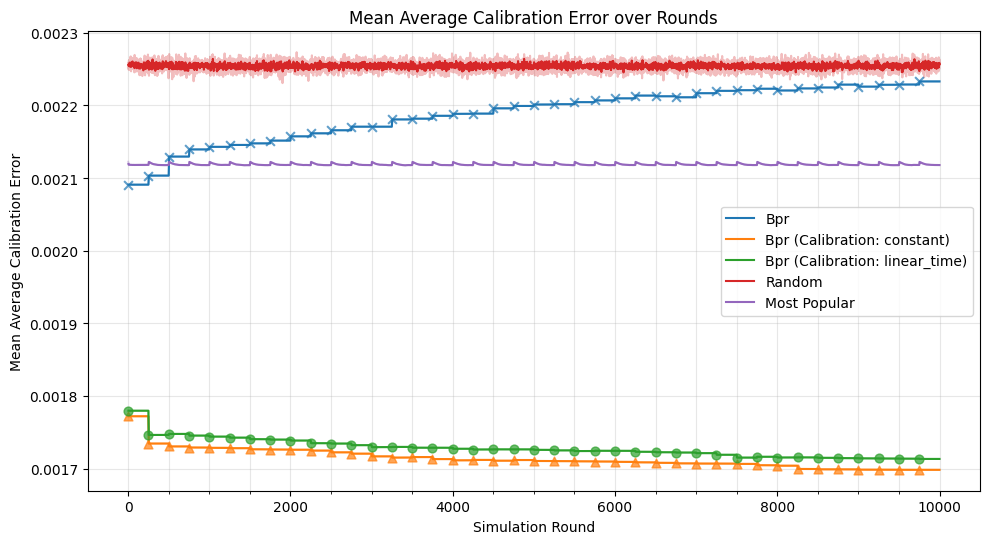

In [5]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="mace", title=None, graph="line", plot_retrain_points=True,  window_size=5)

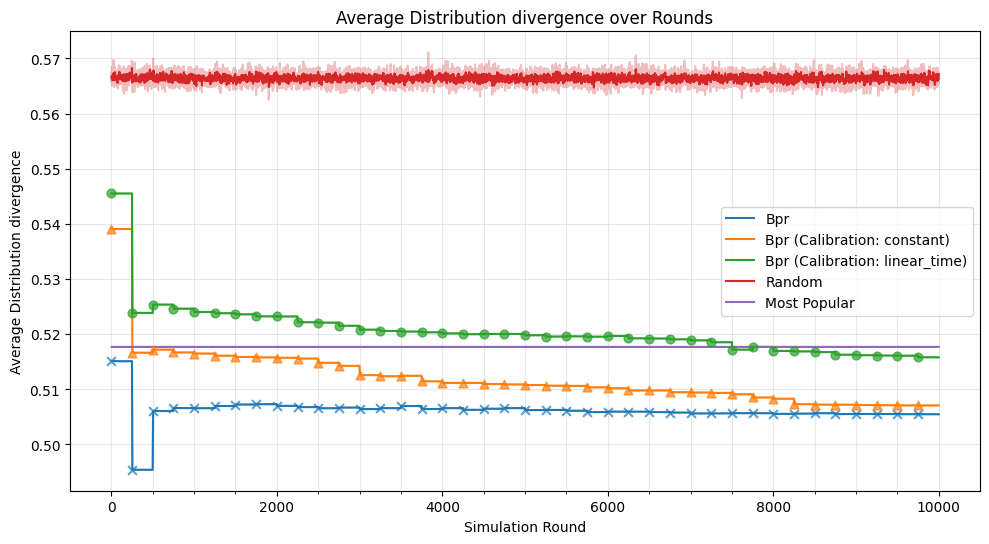

In [6]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="diver", title=None, graph="line", plot_retrain_points=True,  window_size=5)

### Analisando diversidade


Olhando a métrica, o problema é como eu to plotando o gráfico: Na verdade eu to plotando diversidade BASEADA em ILS. Então faz sentido a diversidade ir caindo ao longo do tempo, os itens tão ficando mais parecidos. Agora, no caso do movielens, eu acho que eu tava plotando o ILS.

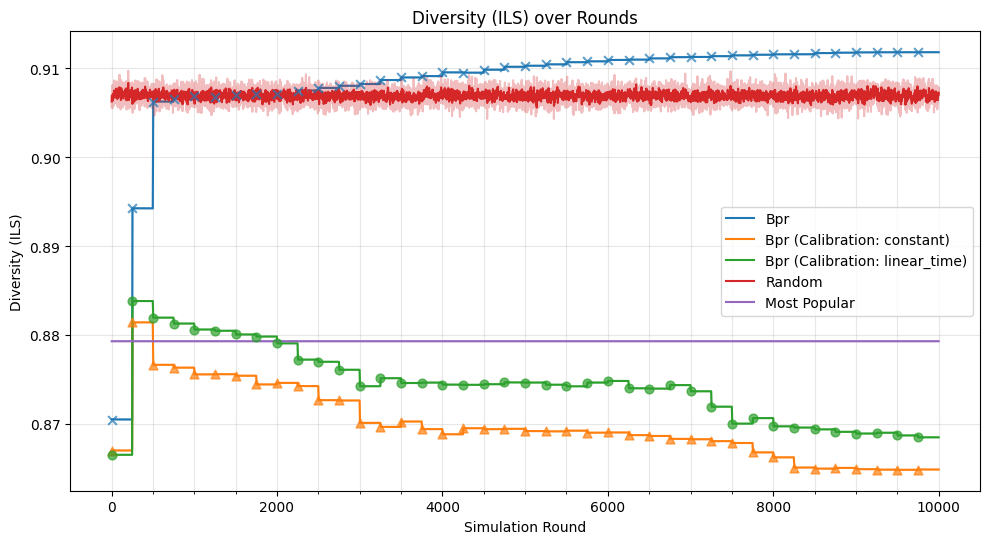

In [7]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec, most_popular], metric_name="div", title=None, graph="line", plot_retrain_points=True,  window_size=5)

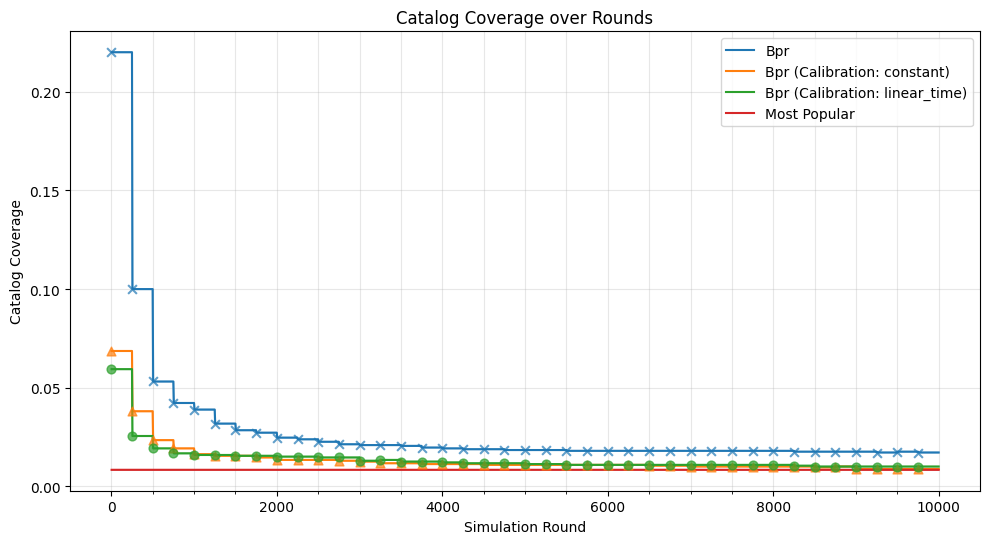

In [8]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, most_popular], metric_name="coverage", title=None, graph="line", plot_retrain_points=True,  window_size=5)

Conclusões acompanham movielens: cobertura de catálogo decresce ao longo do tempo em ambos os casos (Parece ser efeito do feedback loop). Cobertura de catálogo de calibração é menor por si.

## Analisando viés de popularidade

Nos últimos dois plots eu removo o random porque ele sai muito do padrão

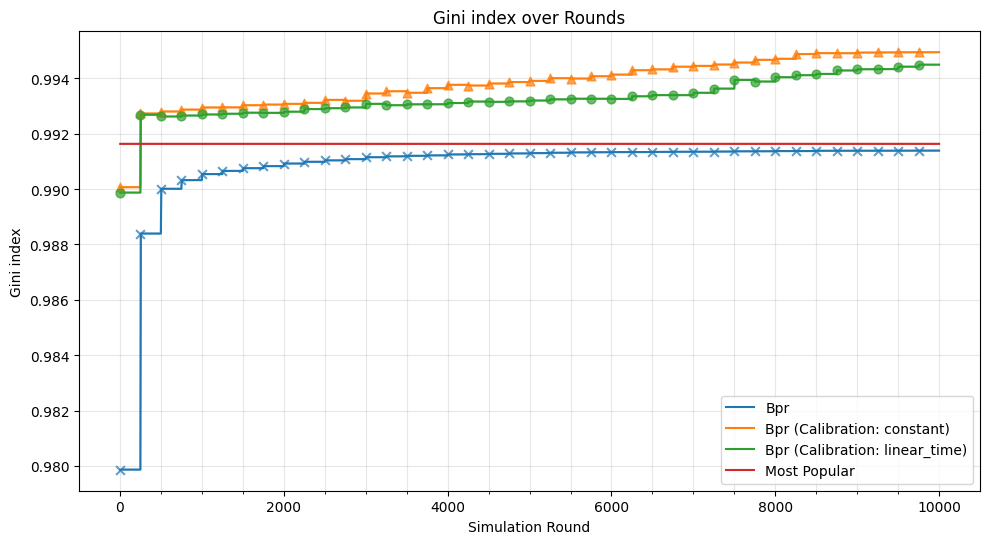

In [9]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, most_popular], metric_name="gini", title=None, graph="line", plot_retrain_points=True,  window_size=5)

Similar. Recomendações beeeem concentradas. Mas são mais concentradas ainda pra calibração.